In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression


In [7]:
amazon = pd.read_csv('/content/amazon_reviews.csv')

In [8]:
amazon.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [9]:
amazon.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [10]:
amazon.shape

(4915, 12)

In [74]:
df = amazon[['reviewText', 'total_vote']]
df.head()

,reviewText,total_vote
0,No issues.,0
1,"Purchased this for my device, it worked as adv...",0
2,it works as expected. I should have sprung for...,0
3,This think has worked out great.Had a diff. br...,0
4,"Bought it with Retail Packaging, arrived legit...",0


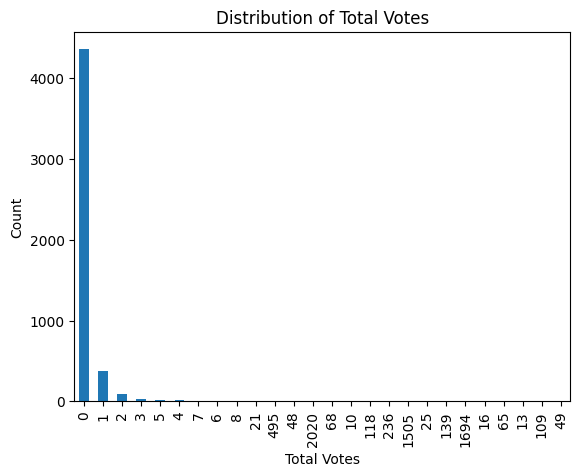

In [75]:
df['total_vote'].value_counts().plot(kind='bar')
plt.xlabel('Total Votes')
plt.ylabel('Count')
plt.title('Distribution of Total Votes')
plt.xticks(rotation=90)
plt.show()

In [76]:
df.isna().sum()

,0
reviewText,1
total_vote,0


In [77]:
df['reviewText'].fillna('', inplace=True)

In [78]:
def map_reiew(x):
  if x < 3:
    return 'Negative'
  elif x == 3:
    return 'Neutral'
  else:
    return 'Positive'


In [79]:
df['review'] = df['total_vote'].apply(lambda x: map_reiew(x))

In [80]:
df.head()

,reviewText,total_vote,review
0,No issues.,0,Negative
1,"Purchased this for my device, it worked as adv...",0,Negative
2,it works as expected. I should have sprung for...,0,Negative
3,This think has worked out great.Had a diff. br...,0,Negative
4,"Bought it with Retail Packaging, arrived legit...",0,Negative


In [82]:
import nltk
nltk.download('stopwords')

stopwords = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [85]:

total_stopwords = set(stopwords)
negative_stop_words = set(word for word in total_stopwords if 'n,' in word or 'no'
in word)
final_stopwords = total_stopwords - negative_stop_words

final_stopwords.add('one')
print(final_stopwords)

{'couldn', 'am', 'yourselves', 'both', 'me', 'shouldn', 'ain', "don't", 'won', "that'll", 'other', 'myself', 'is', 's', 'as', 'was', 'd', 'before', 'so', 'them', "you'd", "she'd", 'yours', 'does', "hadn't", "he'll", 'have', 'needn', 'then', 'our', 'himself', "they've", 'if', 'it', 'didn', 'has', "she'll", 'down', 'because', "shan't", 'or', "it'd", 'weren', 'will', 'on', 'where', "we'd", 'of', "should've", 'and', 'some', 'in', 'by', "mightn't", 'we', 'being', "it's", 'until', 'to', 'that', 'him', "shouldn't", 'doing', 'when', 'mightn', 'y', 'while', "i'd", 'isn', "isn't", "couldn't", "i'll", 'whom', 'between', 'few', 'theirs', 'against', 'an', 'from', "you'll", 'only', 'each', 'out', 'the', 'be', 'haven', 'here', 'ma', "they'd", 'hadn', "i'm", 'wasn', 'my', 'having', 'shan', "wouldn't", 'why', 'just', 'for', "mustn't", "i've", 'over', 'those', 'should', "he's", 'this', 'he', 'are', 't', 'through', 'too', "it'll", 'wouldn', "aren't", 'very', 'again', "they'll", 'during', 'up', 'more', "w

In [87]:
import re
import string
import nltk
from nltk.stem import PorterStemmer

In [88]:
nltk.Stemmer = PorterStemmer()
HTMLTAGS = re.compile('<.*?>')
table = str.maketrans(dict.fromkeys(string.punctuation))
review_digital  = str.maketrans('', '', string.digits)
MULTIPLE_WHITESPCE = re.compile(r'\s+')

In [94]:
from os import remove
def Text_prepocessor(review):
  review = review.lower()
  review = re.sub(HTMLTAGS, '', review)
  review = review.translate(table)
  review = review.translate(review_digital)
  review = re.sub(MULTIPLE_WHITESPCE, ' ', review)
  review = ' '.join([nltk.stemmer.stem(word) for word in review.split() if word not in final_stopwords])
  return review


In [95]:
text = 'Coffee is very week i have to use packs to make 4 cups of coffee.'

In [96]:
Text_prepocessor(text)

'coffe week use pack make cup coffe'

In [98]:
def generate_wclome(text):
  stopwords = set(STOPWORDS)
  wordcloud = WordCloud(width = 800, height = 800,
                        background_color ='white',
                        stopwords = stopwords,
                        min_font_size = 10).generate(text)

  plt.figure(figsize = (8, 8), facecolor = None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad = 0)
  plt.show()



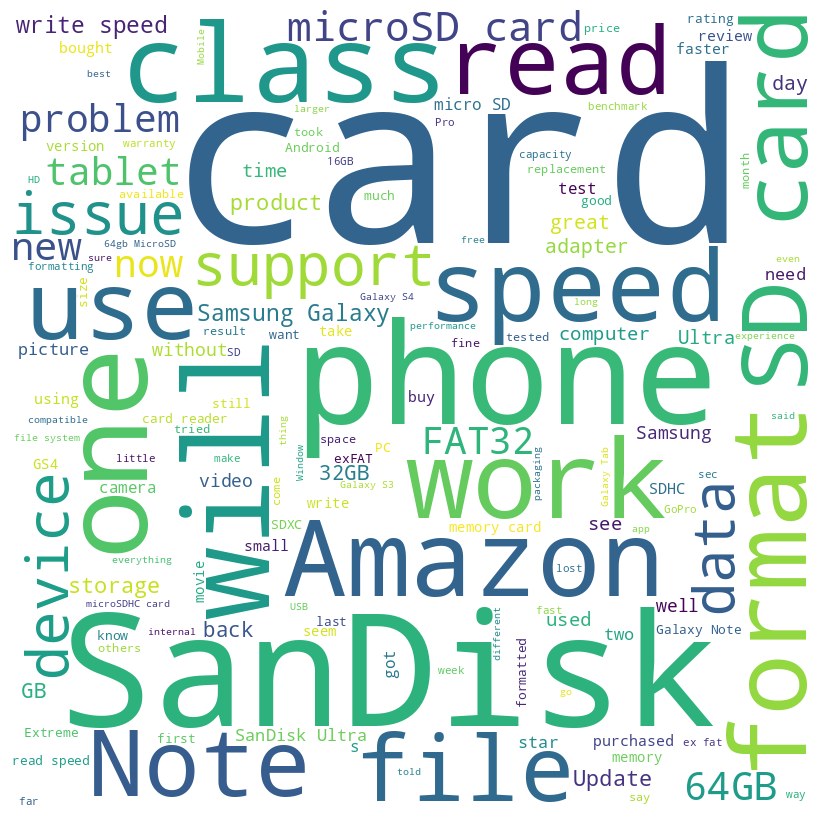

In [100]:
pos = df.loc[df.review =='Positive'].Text
text = " ".join(review for review in pos)
generate_wclome(text)

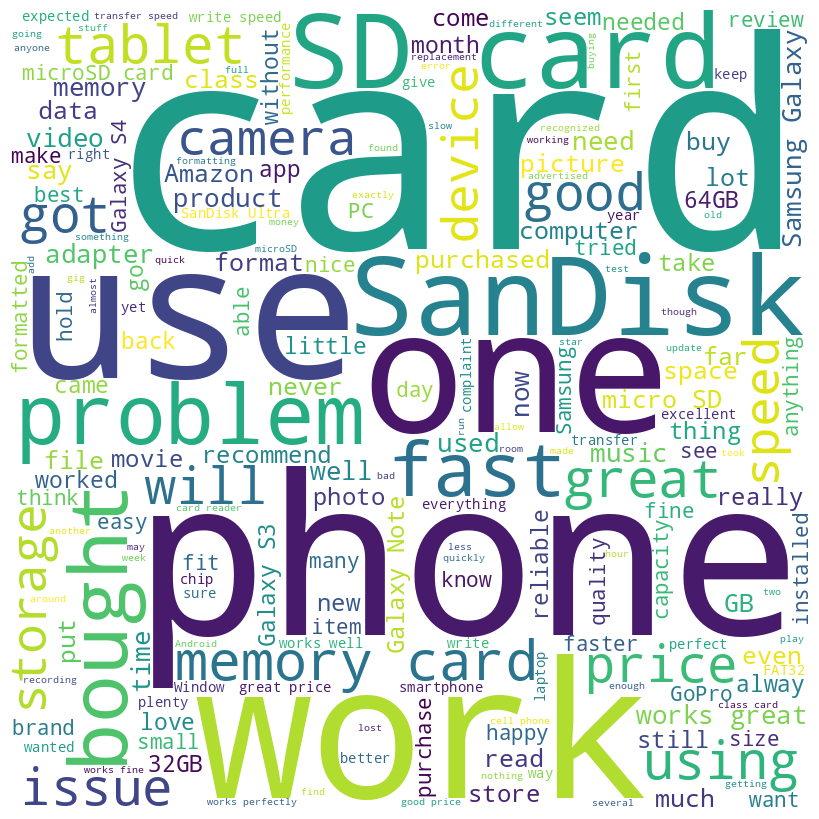

In [104]:
Neg = df.loc[df.review == 'negatve'].reviewText
text = " ".join(review for review in Neg)
generate_wclome(text)

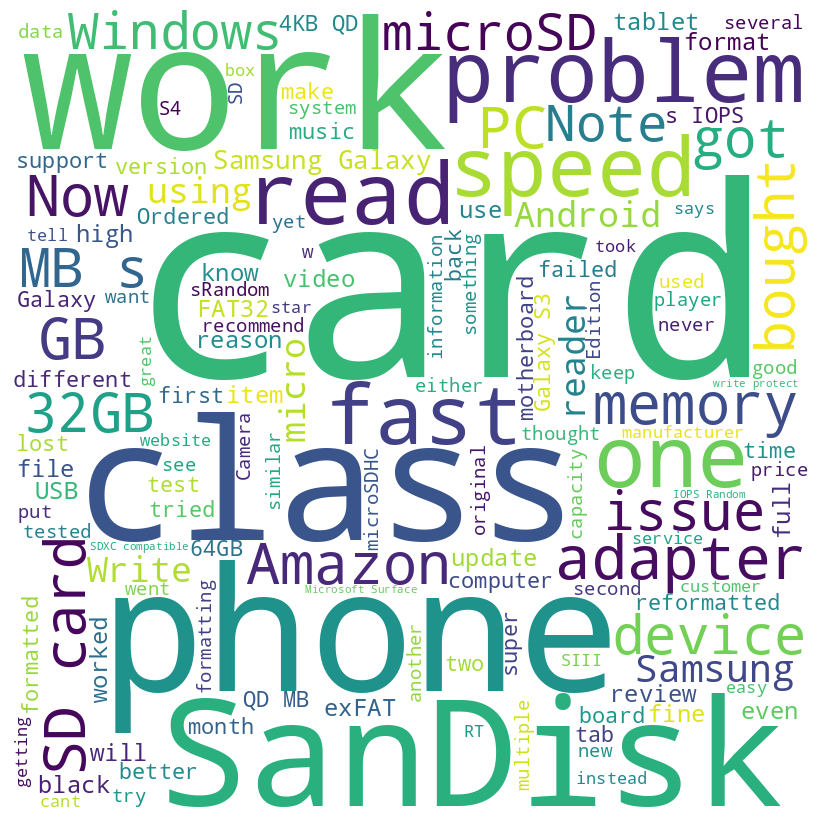

In [105]:
Net = df.loc[df.review == 'Neutral'].reviewText
text = " ".join(review for review in Net)
generate_wclome(text)

In [107]:
X = df.reviewText
y = df.review

In [108]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3932,), (983,), (3932,), (983,))

In [113]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [114]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [115]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [117]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  y_pred_test = model.predict(X_test)
  print()
  print(model)
  print('Accuracy Score: ', accuracy_score(y_test, y_pred))
  print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))
  print('\n', 40*'-')
  print('\n')

In [121]:
C = [0.001, 0.2, 0.4, 0.6, 0.8, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for c in C:
  log_odel = LogisticRegression(C=c)
  train_and_evaluate(log_odel, X_train_bow, y_train, X_test_bow, y_test)


LogisticRegression(C=0.001)
Accuracy Score:  0.9816887080366226
Confusion Matrix: 
 [[963   0   2]
 [  6   0   0]
 [ 10   0   2]]

 ----------------------------------------



LogisticRegression(C=0.2)
Accuracy Score:  0.9796541200406917
Confusion Matrix: 
 [[961   0   4]
 [  6   0   0]
 [ 10   0   2]]

 ----------------------------------------



LogisticRegression(C=0.4)
Accuracy Score:  0.9796541200406917
Confusion Matrix: 
 [[961   0   4]
 [  6   0   0]
 [ 10   0   2]]

 ----------------------------------------



LogisticRegression(C=0.6)
Accuracy Score:  0.982706002034588
Confusion Matrix: 
 [[963   0   2]
 [  6   0   0]
 [  9   0   3]]

 ----------------------------------------



LogisticRegression(C=0.8)
Accuracy Score:  0.982706002034588
Confusion Matrix: 
 [[963   0   2]
 [  6   0   0]
 [  9   0   3]]

 ----------------------------------------



LogisticRegression(C=1)
Accuracy Score:  0.982706002034588
Confusion Matrix: 
 [[963   0   2]
 [  6   0   0]
 [  9   0   3]]

 --

In [124]:
from sklearn.naive_bayes import MultinomialNB

In [125]:
alphas = [0, 0.2, 0.6, 0.6, 1]
for alpha in alphas:
  nb_model  = MultinomialNB(alpha=alpha)
  train_and_evaluate(nb_model, X_train_bow, y_train, X_test_bow, y_test)


MultinomialNB(alpha=0)
Accuracy Score:  0.9816887080366226
Confusion Matrix: 
 [[965   0   0]
 [  6   0   0]
 [ 12   0   0]]

 ----------------------------------------



MultinomialNB(alpha=0.2)
Accuracy Score:  0.9806714140386572
Confusion Matrix: 
 [[962   1   2]
 [  6   0   0]
 [ 10   0   2]]

 ----------------------------------------



MultinomialNB(alpha=0.6)
Accuracy Score:  0.9816887080366226
Confusion Matrix: 
 [[964   1   0]
 [  6   0   0]
 [ 11   0   1]]

 ----------------------------------------



MultinomialNB(alpha=0.6)
Accuracy Score:  0.9816887080366226
Confusion Matrix: 
 [[964   1   0]
 [  6   0   0]
 [ 11   0   1]]

 ----------------------------------------



MultinomialNB(alpha=1)
Accuracy Score:  0.9806714140386572
Confusion Matrix: 
 [[964   1   0]
 [  6   0   0]
 [ 12   0   0]]

 ----------------------------------------




In [126]:
bmodel = LogisticRegression(C=1, max_iter=500, random_state=1)
bmodel.fit(X_train_bow, y_train)

LogisticRegression(C=1, max_iter=500, random_state=1)

In [127]:
y_pred_train = bmodel.predict(X_train_bow)
y_pred_test = bmodel.predict(X_test_bow)

In [129]:
print("Train accuracy score : {accuracy_score(y_train, y_pred_train)}")
print("Test accuracy score : {accuracy_score(y_test, y_pred_test)}")

Train accuracy score : {accuracy_score(y_train, y_pred_train)}
Test accuracy score : {accuracy_score(y_test, y_pred_test)}


In [131]:
def plot_cm(y_test, y_pred):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted labels')
  plt.ylabel('True labels')
  plt.title('Confusion Matrix')
  plt.show()